<a href="https://colab.research.google.com/github/bobisawsome1/cap-comp215/blob/main/Langstons_Ant_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project: Langstons Ant

Author: Nicholas Mason

Imports

In [1]:
import numpy as np
import time
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import animation

Animation set ups copied from labs

In [2]:
def plot_2d_array(array, axes=None, title='', cmap='Blues', **options):
    """
    Plot the 2D array as an image on the given axes  1's will be dark blue, 0's will be light blue.

    :param axes: the axes to plot on, or None to use the `plt.gca()` (current axes)
    :param options: keyword arguments passed directly to `plt.imshow()`
           see https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html
    """
    axes = axes or plt.gca()  # If not axes are provided, draw on current axes
    axes.set_title(title)
    # Turn off axes labels and tick marks
    axes.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False ,
                     labelbottom=False, labeltop=False, labelleft=False, labelright=False,)
    # Defaults for displaying a "matrix" with hard-pixel boundaries and (0,0) at top-left
    options = {**dict(interpolation='nearest', origin='upper'), **options}
    axes.imshow(array, cmap=cmap, **options)


class Animation2D:
    """
      Animates any 2D model with a step() method and a draw() method, using matplotlib
      model.step() should take no parameters - just step the model forward one step.
      model.draw() should take 2 parameters, the matpltolib axes to draw on and an integer step number
    """

    def __init__(self, model, frames=50, figsize=(8, 8)):
        """
        :param model: the simulation object to animate, with step() and draw(axes, step) methods
        :param frames: number of animation frames to generate
        """
        self.model = model
        self.frames = frames
        self.fig, self.ax = plt.subplots(figsize=figsize)

    def animation_step(self, step):
        """ Step the model forward and draw the plot """
        if step > 0:
            self.model.step()
        self.model.draw(self.ax, step=step)

    def show(self):
        """ return the matplotlib animation object, ready for display """
        anim = animation.FuncAnimation(self.fig, self.animation_step, frames=self.frames)
        plt.close()  # this ensures the last frame is not shown as a separate plot
        return anim

    def animate(self, interval=None):
        """ Animate the model simulation directly in the notebook display block """
        from IPython.display import clear_output
        try:
            for i in range(self.frames):
                clear_output(wait=True)  # clear the IPython display
                self.ax.clear()          # clear old image from the axes (fixes a performance issue)
                plt.figure(self.fig)     # add the figure back to pyplot ** sigh **
                self.animation_step(i)
                plt.show()               # show the current animation frame (pyplot then closes and throws away figure ** sigh **)
                if interval:
                    time.sleep(interval)
        except KeyboardInterrupt:
            pass

When creating our ant object we will start off by giving it a starting location. We will also give it the state that it will be walking thgrough. Along with initializing a direction variable.


For our step function we will want to find what colour tile we are currently standing on.
- If we're standing on a black(1) tile then we will turn 90 degrees counter clockwise
- If we're on a white(0) tile then we will turn 90 degrees clockwise

As its easier for my head to understand i will write the code so when we do a whole loop(go past 360 or we start heading into the negatives) then i will set my direction to the coresponding direction

In [3]:
class LangtonsAnt():
  def __init__(self, start_x, start_y, n_rows, n_cols):
    self.x = start_x
    self.y = start_y
    self.direction = 0 #we will check divisibilities of this value to determine what direction we will move
    self.n_rows = n_rows
    self.n_cols = n_cols

    #create random grid of 1s and 0s for our state
    self.state = np.random.choice([0, 1], (n_cols, n_rows), p=[0.5, 1 - 0.5])

  def step(self):
    #get the value of the current tile were on
    current_tile = self.state[self.y][self.x]

    #If your on a black tile
    if(current_tile == 1):
      #If turning left from our current direction will turn us left from straight then set our direction to 270(left) for an easier check later
      if(self.direction - 90 < 0):
        self.direction = 270

      #Everyother time simply just subtract 90 from our current direction
      else:
        self.direction -= 90

      #change the tile to white
      self.state[self.y][self.x] = 0

    #If your on a white tile
    elif(current_tile == 0):
      #Similar to above if weve done a whole loop and are going to turn past 360(straight up) then just set our direction to 90(right) again for easier checking later
      if(self.direction + 90 > 360):
        self.direction = 90

      #everyother time just add 90 degrees to our direction
      else:
        self.direction += 90

      #change the tile to black
      self.state[self.y][self.x] = 1

    #move ant in x or y depending on their current direction
    match self.direction:
      case 0: self.y -= 1
      case 90: self.x += 1
      case 180: self.y += 1
      case 270: self.x -= 1
      case 360: self.y -= 1

    #Making ant wrap around grid
    if self.y < 0:
      self.y = self.n_cols - 1

    elif self.y >= self.n_cols:
      self.y = 0

    if self.x < 0:
      self.x = self.n_rows - 1

    elif self.x >= self.n_rows:
      self.x = 0



  def draw(self, axes=None, step=''):
        axes = axes or plt.gca()   # use pyplot's current axes if none are provided.
        plot_2d_array(self.state, axes, title=f"Langtons Ant {step + 1}")


This is the basic set up for our ant. Below we run through some steps of it. And draw it so it looks pretty

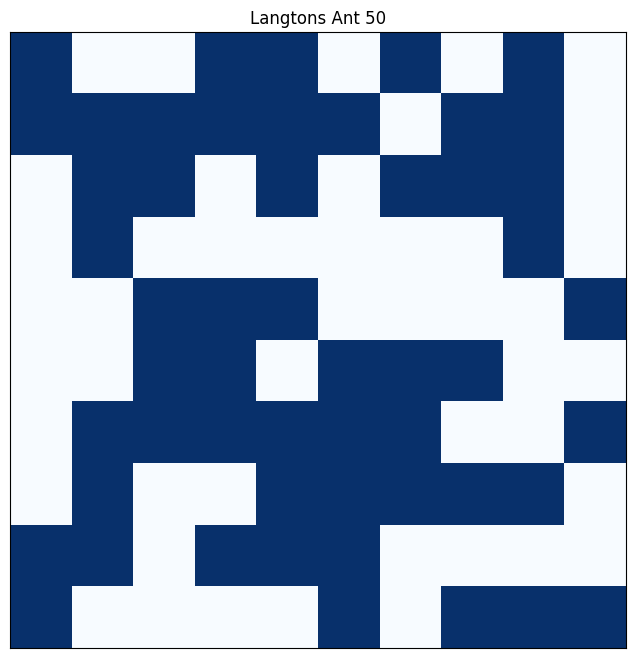

In [4]:
trial_ant = LangtonsAnt(5, 5, 10, 10)

animation_ant = Animation2D(trial_ant, frames=50)
animation_ant.animate(interval=0.1)

To make this even simpler we will create a function that takes a size for our grid and the amout of steps that we want to simulate. Essentially using the same code written above.

In [5]:
def Ant_Trial(trial_rows, trial_cols, generations, interval):
  #find the middle point for our start
  starting_x = trial_cols//2
  starting_y = trial_rows//2
  frank = LangtonsAnt(starting_x, starting_y, trial_rows, trial_cols)

  animating_frank = Animation2D(frank, frames=generations)
  animating_frank.animate(interval=interval)

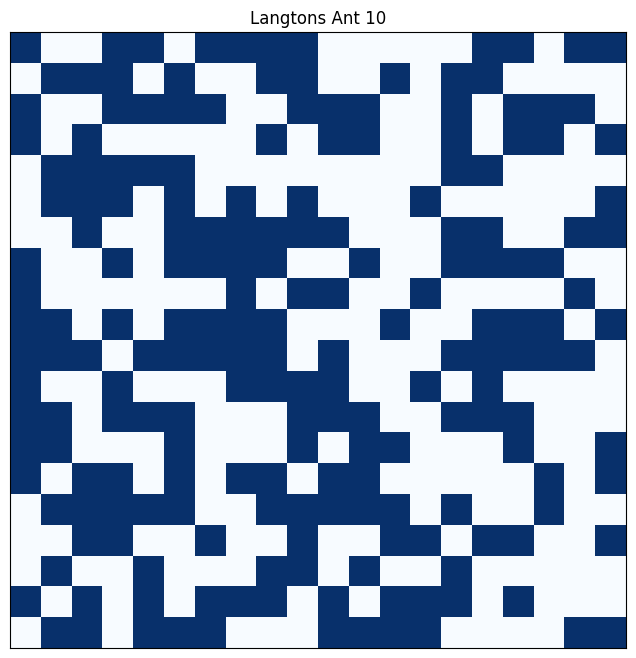

In [6]:
Ant_Trial(20,20,10,0.1)

# Algorithm Analysis

I believe that the big O for this in O(t(generations)). This is because we might not touch all the squares of our nxm grid, and the guarantee that a high value will give us more time is when we add generations, obviously meaning more steps to run through.

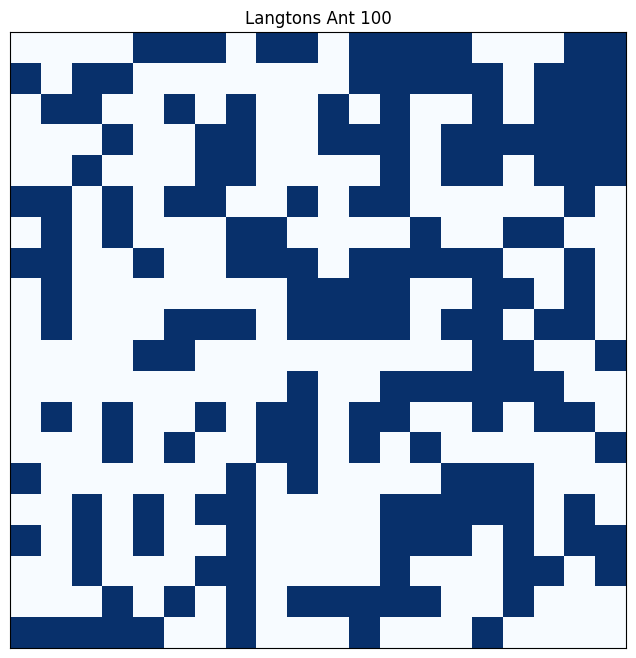

[1.504429546999745, 3.8566580989991053, 6.334294379001221, 11.834214152999266, 13.619753193999713]


Text(0, 0.5, 'time (seconds)')

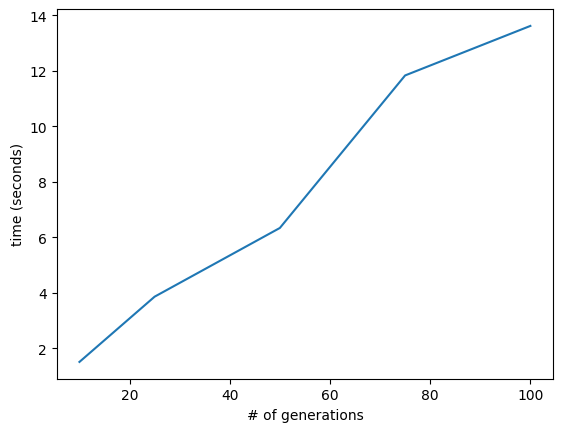

In [11]:
#Experiment with different generations
import timeit

gen_list = [10, 25, 50, 75, 100]
results = []

for generation in gen_list:
  t = timeit.Timer(lambda:Ant_Trial(20, 20, generation, 0))
  results.append(t.timeit(number=1))

print(results)
plt.plot(gen_list, results)
plt.xlabel('# of generations')
plt.ylabel('time (seconds)')
plt.show()

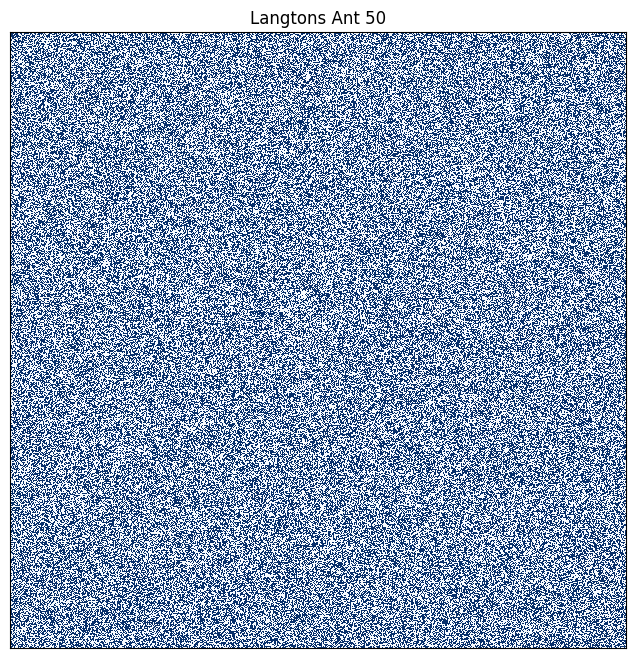

[6.350981845998831, 7.01796036199994, 6.157016238001233, 11.872249682999609, 19.40358310299962]


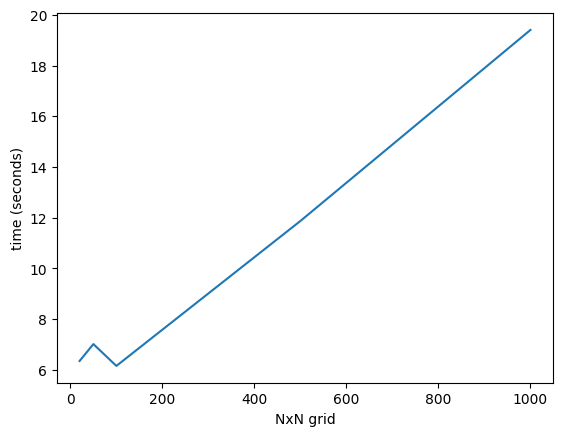

In [12]:
#Experiment with different generations
import timeit

grid_list = [20, 50, 100, 500, 1000]
results = []

for grid in grid_list:
  t = timeit.Timer(lambda:Ant_Trial(grid, grid, 50, 0))
  results.append(t.timeit(number=1))

print(results)
plt.plot(grid_list, results)
plt.xlabel('NxN grid')
plt.ylabel('time (seconds)')
plt.show()

As we can see from running the code above. When we add more generations our time goes up somewhat linearly, this is pretty much what i expected.

What i didnt expect however is that when we add spaces to our grid our time also goes up. I thought that because we are only searching the spots around our Ant then the time taken to search around the ant would be the same. This result might be because we are drawing our results. This means that when we produce the grid we go through more data leading to more time being taken up.

These results really surprised me and show that maybe i dont fully understand time complexity or that when predicting what would happen i didnt consider the fact taht we would have to draw every square.